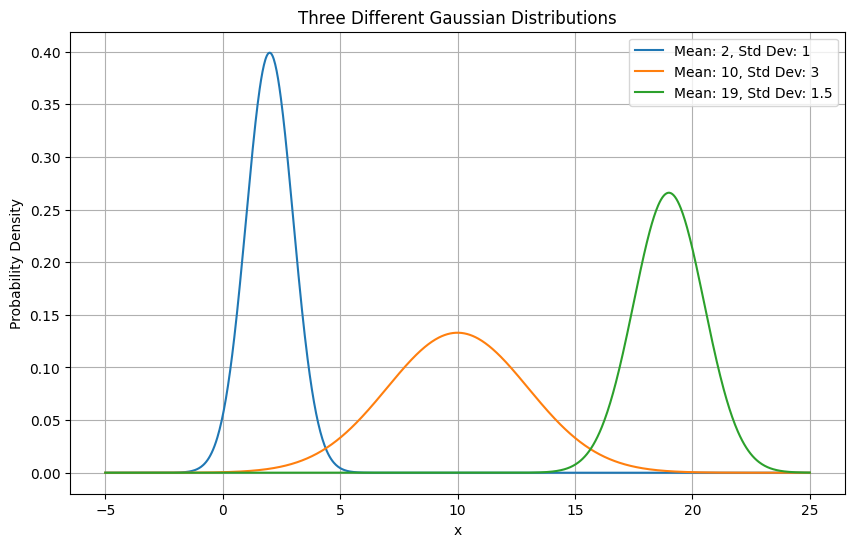

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Define parameters for the three Gaussian distributions
mean1, std1 = 2, 1
mean2, std2 = 10, 3
mean3, std3 = 19, 1.5

# Generate x values for plotting
x = np.linspace(-5, 25, 1000)

# Calculate the probability density function (PDF) for each distribution
pdf1 = norm.pdf(x, mean1, std1)
pdf2 = norm.pdf(x, mean2, std2)
pdf3 = norm.pdf(x, mean3, std3)

# Plot the distributions
plt.figure(figsize=(10, 6))
plt.plot(x, pdf1, label=f'Mean: {mean1}, Std Dev: {std1}')
plt.plot(x, pdf2, label=f'Mean: {mean2}, Std Dev: {std2}')
plt.plot(x, pdf3, label=f'Mean: {mean3}, Std Dev: {std3}')

# Add labels and title
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.title('Three Different Gaussian Distributions')
plt.legend()
plt.grid(True)
plt.show()

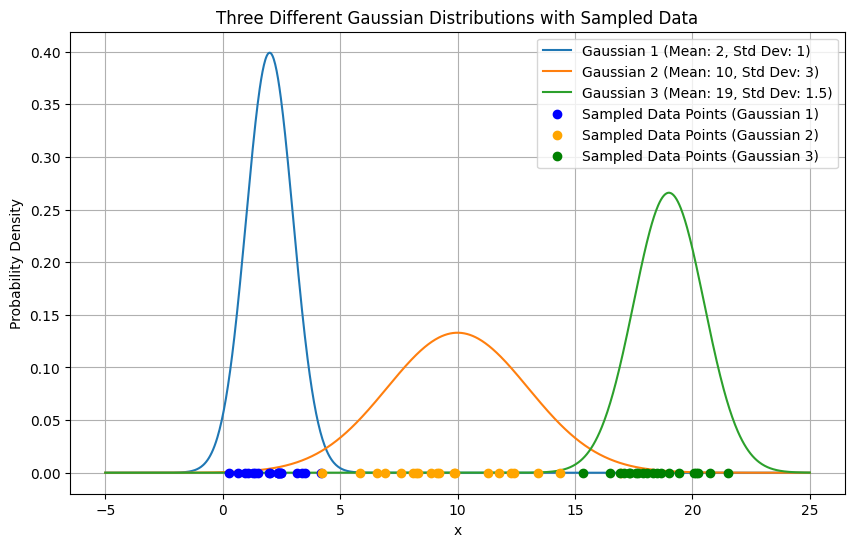

In [ ]:
# Sample 20 data points from each Gaussian distribution
sample_points_1 = np.random.normal(mean1, std1, 20)
sample_points_2 = np.random.normal(mean2, std2, 20)
sample_points_3 = np.random.normal(mean3, std3, 20)

# Plot the sampled data points and the distributions on a separate graph
plt.figure(figsize=(10, 6))
plt.plot(x, pdf1, label=f'Gaussian 1 (Mean: {mean1}, Std Dev: {std1})')
plt.plot(x, pdf2, label=f'Gaussian 2 (Mean: {mean2}, Std Dev: {std2})')
plt.plot(x, pdf3, label=f'Gaussian 3 (Mean: {mean3}, Std Dev: {std3})')
plt.scatter(sample_points_1, np.zeros_like(sample_points_1), color='blue', zorder=5, label='Sampled Data Points (Gaussian 1)')
plt.scatter(sample_points_2, np.zeros_like(sample_points_2), color='orange', zorder=5, label='Sampled Data Points (Gaussian 2)')
plt.scatter(sample_points_3, np.zeros_like(sample_points_3), color='green', zorder=5, label='Sampled Data Points (Gaussian 3)')

plt.xlabel('x')
plt.ylabel('Probability Density')
plt.title('Three Different Gaussian Distributions with Sampled Data')
plt.legend()
plt.grid(True)
plt.show()

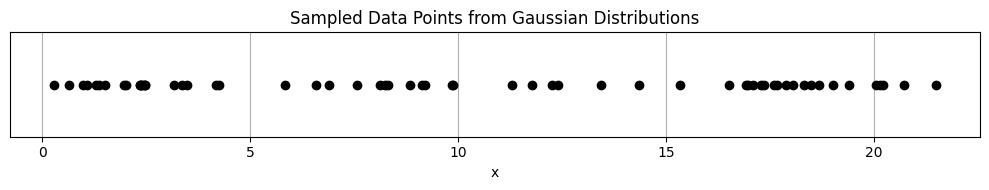

In [ ]:
# Plot only the sampled data points
plt.figure(figsize=(10, 2))
plt.scatter(sample_points_1, np.zeros_like(sample_points_1), zorder=5, color='black')
plt.scatter(sample_points_2, np.zeros_like(sample_points_2), zorder=5, color='black')
plt.scatter(sample_points_3, np.zeros_like(sample_points_3), zorder=5, color='black')

plt.xlabel('x')
plt.title('Sampled Data Points from Gaussian Distributions')
plt.yticks([])  # Hide the y-axis
plt.tight_layout()
plt.grid(True)
plt.show()

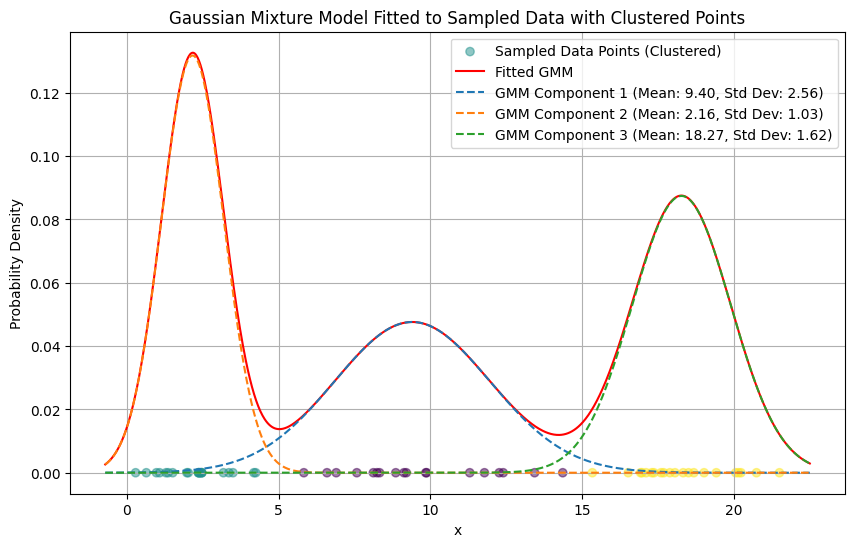

In [ ]:
from sklearn.mixture import GaussianMixture

# Combine all sampled data points
all_sample_points = np.concatenate((sample_points_1, sample_points_2, sample_points_3))

# Reshape the data for the GMM
all_sample_points = all_sample_points.reshape(-1, 1)

# Create and fit the Gaussian Mixture Model
# We know there are 3 underlying components, so we set n_components=3
gmm = GaussianMixture(n_components=3, random_state=0)
gmm.fit(all_sample_points)

# Predict the cluster for each data point
cluster_assignments = gmm.predict(all_sample_points)

# Generate x values for plotting the GMM components
x_gmm = np.linspace(all_sample_points.min() - 1, all_sample_points.max() + 1, 1000).reshape(-1, 1)

# Calculate the probability density of the GMM components
logprob = gmm.score_samples(x_gmm)
pdf_gmm = np.exp(logprob)

# Plot the original data points and the fitted GMM
plt.figure(figsize=(10, 6))
# Scatter plot with colors based on cluster assignments
plt.scatter(all_sample_points, np.zeros_like(all_sample_points), c=cluster_assignments, cmap='viridis', alpha=0.5, label='Sampled Data Points (Clustered)')
plt.plot(x_gmm, pdf_gmm, color='red', label='Fitted GMM')

# Plot the individual components of the GMM
for i in range(gmm.n_components):
    mean = gmm.means_[i, 0]
    std = np.sqrt(gmm.covariances_[i, 0, 0])
    weight = gmm.weights_[i]
    pdf_component = weight * norm.pdf(x_gmm[:, 0], mean, std)
    plt.plot(x_gmm, pdf_component, linestyle='--', label=f'GMM Component {i+1} (Mean: {mean:.2f}, Std Dev: {std:.2f})')


plt.xlabel('x')
plt.ylabel('Probability Density')
plt.title('Gaussian Mixture Model Fitted to Sampled Data with Clustered Points')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Show the mixing coefficients for each learned gaussian component
print("Mixing coefficients (weights) for each GMM component:")
for i, weight in enumerate(gmm.weights_):
    print(f"Component {i+1}: {weight:.4f}")

Mixing coefficients (weights) for each GMM component:
Component 1: 0.3055
Component 2: 0.3392
Component 3: 0.3553


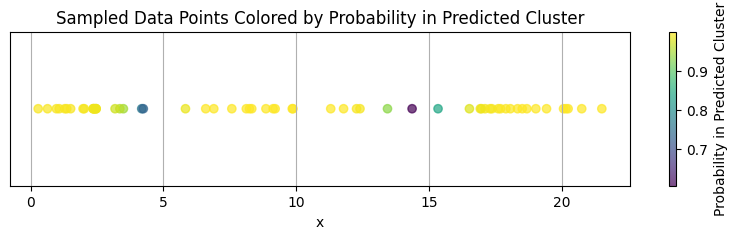

In [ ]:
# Get the probabilities of each data point belonging to each cluster
probabilities = gmm.predict_proba(all_sample_points)

# Get the probability of the predicted cluster for each data point
predicted_cluster_probabilities = probabilities[np.arange(len(all_sample_points)), cluster_assignments]

# Plot the data points colored by the probability they belong to their assigned cluster
plt.figure(figsize=(10, 2))
plt.scatter(all_sample_points, np.zeros_like(all_sample_points), c=predicted_cluster_probabilities, cmap='viridis', alpha=0.7)
plt.xlabel('x')
plt.title('Sampled Data Points Colored by Probability in Predicted Cluster')
plt.yticks([]) # Hide y-axis ticks as they are not meaningful for a 1D scatter plot
plt.colorbar(label='Probability in Predicted Cluster')
plt.grid(True)
plt.show()